[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lalvim/DataMining/blob/main/notebooks/unidade_05/05_04_arvores_de_decisao.ipynb)

# Unidade V — Classificação e Regressão

## Árvores de decisão

**Carga estimada:** 3 horas  
**Pré-requisitos:** processo de classificação, matriz de confusão e pandas.

> **Pergunta norteadora:** como uma sequência de perguntas divide os dados em grupos progressivamente mais homogêneos?

Neste notebook, árvores são estudadas como instrumentos de descoberta e comunicação de padrões. A ênfase está em compreender as divisões, ler as regras e reconhecer quando uma árvore começa a memorizar particularidades do treino.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- identificar raiz, nós internos, ramos e folhas;
- interpretar uma árvore como um conjunto de regras do tipo **SE–ENTÃO**;
- explicar intuitivamente pureza e impureza;
- calcular o índice Gini antes e depois de uma divisão simples;
- percorrer uma árvore para classificar novos casos;
- reconhecer sobreajuste pela diferença entre treino e teste;
- explicar pré-poda e pós-poda;
- interpretar importância de atributos como pista descritiva, não como efeito causal.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.tree import (
    DecisionTreeClassifier,
    export_text,
    plot_tree,
)

RANDOM_STATE = 42

## 1. Uma árvore é um fluxograma de decisões

Uma árvore de decisão contém:

- **raiz:** primeira pergunta aplicada a todos os exemplos;
- **nó interno:** pergunta que divide um subconjunto;
- **ramo:** resultado possível da pergunta;
- **folha:** previsão final e distribuição das classes naquele grupo.

Para classificar um objeto, percorremos um único caminho da raiz até uma folha. Cada caminho pode ser convertido em uma regra:

> **SE** atraso > 1,5 **E** contrato mensal = 1, **ENTÃO** prever cancelamento.

A árvore aprende as perguntas e os pontos de corte a partir dos dados de treino. Ela não descobre automaticamente regras causais; descreve separações que ajudam a prever o alvo.

## 2. Como a árvore cresce

A construção segue uma estratégia recursiva de divisão e conquista:

1. começar com todos os exemplos em um nó;
2. avaliar divisões candidatas;
3. escolher uma divisão que reduza a mistura das classes;
4. repetir o procedimento em cada subconjunto;
5. parar segundo critérios definidos e criar folhas.

O procedimento é **guloso**: escolhe uma boa divisão no nó atual, sem testar todas as árvores possíveis. Por isso, a árvore obtida é uma solução útil, mas não necessariamente a única nem a melhor árvore global.

## 3. Impureza: quão misturado está um nó?

Para um nó com classes de proporções $p_1,\ldots,p_m$, o índice Gini é

$$
Gini(D)=1-\sum_{i=1}^{m}p_i^2.
$$

Em uma classificação binária:

- $Gini=0$ quando todos os exemplos pertencem à mesma classe;
- $Gini=0{,}5$ quando as classes estão divididas em 50% e 50%;
- valores menores indicam grupos mais homogêneos.

Para avaliar uma divisão em subconjuntos $D_1$ e $D_2$, usamos a média ponderada:

$$
Gini_{\text{divisão}}
=
\frac{|D_1|}{|D|}Gini(D_1)
+
\frac{|D_2|}{|D|}Gini(D_2).
$$

A árvore procura grande redução de impureza:

$$
\Delta Gini=Gini(D)-Gini_{\text{divisão}}.
$$

Entropia e ganho de informação são alternativas descritas no capítulo 6. A ideia central é a mesma: favorecer divisões que separem melhor as classes.

## 4. Exemplo manual de uma divisão

A pequena base sintética representa 12 clientes. O alvo **cancelou** vale 1 para cancelamento e 0 para permanência.

In [2]:
clientes_exemplo = pd.DataFrame({
    "cliente": list("ABCDEFGHIJKL"),
    "atrasos_pagamento": [0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3],
    "chamados_suporte": [0, 1, 2, 3, 0, 1, 3, 1, 2, 4, 2, 5],
    "contrato_mensal": [0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1],
    "cancelou": [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1],
})
clientes_exemplo

,cliente,atrasos_pagamento,chamados_suporte,contrato_mensal,cancelou
0,A,0,0,0,0
1,B,0,1,0,0
2,C,0,2,1,0
3,D,0,3,0,0
4,E,1,0,1,0
5,F,1,1,1,0
6,G,1,3,0,1
7,H,2,1,1,0
8,I,2,2,1,1
9,J,2,4,1,1


Testaremos a pergunta:

$$
\text{atrasos de pagamento}\leq1{,}5?
$$

O grupo esquerdo recebe atrasos 0 ou 1; o direito recebe 2 ou 3. A célula seguinte calcula as proporções e liga cada parcela da fórmula às contagens.

In [3]:
def impureza_gini(valores):
    proporcoes = pd.Series(valores).value_counts(normalize=True)
    return 1 - np.square(proporcoes).sum()

alvo = clientes_exemplo["cancelou"]
grupo_esquerdo = clientes_exemplo.query(
    "atrasos_pagamento <= 1"
)["cancelou"]
grupo_direito = clientes_exemplo.query(
    "atrasos_pagamento > 1"
)["cancelou"]

gini_raiz = impureza_gini(alvo)
gini_esquerdo = impureza_gini(grupo_esquerdo)
gini_direito = impureza_gini(grupo_direito)
gini_apos_divisao = (
    len(grupo_esquerdo) / len(alvo) * gini_esquerdo
    + len(grupo_direito) / len(alvo) * gini_direito
)
reducao_gini = gini_raiz - gini_apos_divisao

resumo_gini = pd.DataFrame({
    "conjunto": ["raiz", "esquerdo: atrasos <= 1", "direito: atrasos > 1"],
    "n": [len(alvo), len(grupo_esquerdo), len(grupo_direito)],
    "permaneceu_0": [
        (alvo == 0).sum(),
        (grupo_esquerdo == 0).sum(),
        (grupo_direito == 0).sum(),
    ],
    "cancelou_1": [
        (alvo == 1).sum(),
        (grupo_esquerdo == 1).sum(),
        (grupo_direito == 1).sum(),
    ],
    "gini": [gini_raiz, gini_esquerdo, gini_direito],
})

assert np.isclose(gini_raiz, 35 / 72)
assert np.isclose(gini_apos_divisao, 0.2761904762)

display(resumo_gini.round(4))
pd.DataFrame({
    "gini_raiz": [gini_raiz],
    "gini_apos_divisao": [gini_apos_divisao],
    "reducao_gini": [reducao_gini],
}).round(4)

,conjunto,n,permaneceu_0,cancelou_1,gini
0,raiz,12,7,5,0.4861
1,esquerdo: atrasos <= 1,7,6,1,0.2449
2,direito: atrasos > 1,5,1,4,0.3200


,gini_raiz,gini_apos_divisao,reducao_gini
0,0.4861,0.2762,0.2099


### Interpretando a conta

Na raiz há sete permanências e cinco cancelamentos:

$$
Gini(D)=1-\left(\frac{7}{12}\right)^2
-\left(\frac{5}{12}\right)^2
=0{,}4861.
$$

Após a divisão:

- à esquerda: seis permanências e um cancelamento, $Gini=0{,}2449$;
- à direita: uma permanência e quatro cancelamentos, $Gini=0{,}3200$.

A impureza ponderada cai para 0,2762, uma redução de 0,2099. Os grupos ainda não são puros, mas a pergunta separou boa parte das classes. O algoritmo compara essa redução com outras perguntas candidatas.

## 5. Da divisão manual à árvore

Agora permitiremos que o algoritmo escolha perguntas entre três atributos. Limitaremos a profundidade a 2 e exigiremos ao menos dois exemplos em cada folha. Essas restrições funcionam como **pré-poda**: interrompem o crescimento antes que cada detalhe vire um ramo.

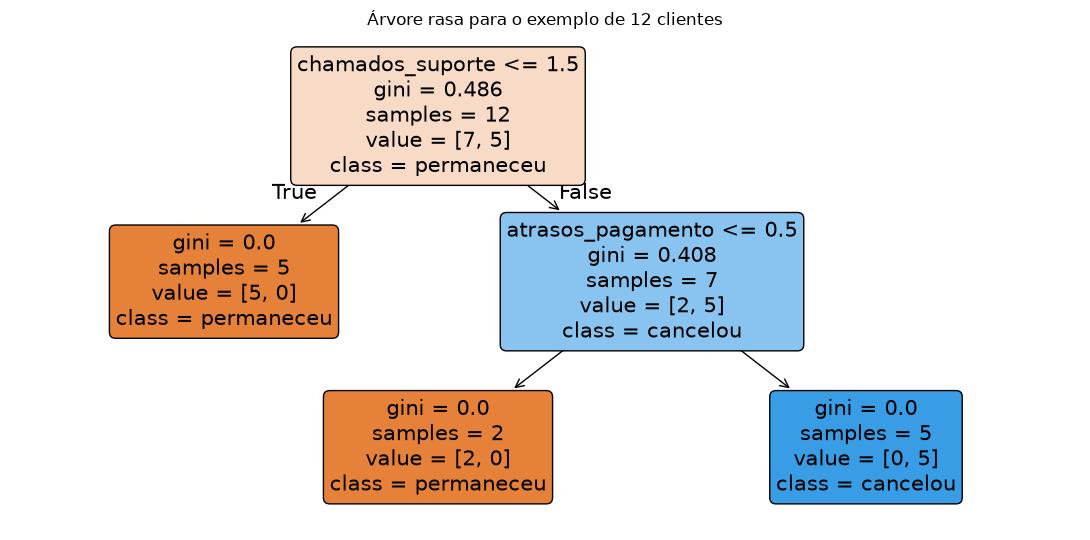

|--- chamados_suporte <= 1.50
|   |--- class: 0
|--- chamados_suporte >  1.50
|   |--- atrasos_pagamento <= 0.50
|   |   |--- class: 0
|   |--- atrasos_pagamento >  0.50
|   |   |--- class: 1



In [4]:
atributos_exemplo = [
    "atrasos_pagamento",
    "chamados_suporte",
    "contrato_mensal",
]
X_exemplo = clientes_exemplo[atributos_exemplo]
y_exemplo = clientes_exemplo["cancelou"]

arvore_pequena = DecisionTreeClassifier(
    criterion="gini",
    max_depth=2,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
)
arvore_pequena.fit(X_exemplo, y_exemplo)

plt.figure(figsize=(11, 5.5))
plot_tree(
    arvore_pequena,
    feature_names=atributos_exemplo,
    class_names=["permaneceu", "cancelou"],
    filled=True,
    rounded=True,
    proportion=False,
)
plt.title("Árvore rasa para o exemplo de 12 clientes")
plt.tight_layout()
plt.show()

print(export_text(arvore_pequena, feature_names=atributos_exemplo))

### Como ler cada caixa

Nas caixas produzidas pela biblioteca:

- a primeira linha contém a pergunta;
- **gini** informa a mistura no nó;
- **samples** informa quantos exemplos chegaram ao nó;
- **value** mostra as contagens das classes [permaneceu, cancelou];
- **class** mostra a classe majoritária prevista.

Um ponto de corte como 1,5 não precisa existir na base. Ele representa o ponto médio entre valores adjacentes 1 e 2. Para ler uma regra, siga todas as condições do caminho; não interprete um nó isolado fora de seu ramo.

### Percorrendo a árvore com novos casos

A tabela abaixo aplica a árvore a dois perfis. A probabilidade exibida é a proporção das classes na folha alcançada, não uma garantia individual.

In [5]:
novos_clientes = pd.DataFrame({
    "atrasos_pagamento": [0, 3],
    "chamados_suporte": [1, 4],
    "contrato_mensal": [0, 1],
}, index=["perfil_1", "perfil_2"])

previsoes = arvore_pequena.predict(novos_clientes)
probabilidades = arvore_pequena.predict_proba(novos_clientes)

resultado_novos = novos_clientes.copy()
resultado_novos["previsao"] = np.where(
    previsoes == 1, "cancelou", "permaneceu"
)
resultado_novos["prob_cancelamento_na_folha"] = probabilidades[:, 1]
resultado_novos

,atrasos_pagamento,chamados_suporte,contrato_mensal,previsao,prob_cancelamento_na_folha
perfil_1,0,1,0,permaneceu,0.0
perfil_2,3,4,1,cancelou,1.0


## 6. Profundidade e sobreajuste

Uma árvore pode continuar dividindo até isolar quase todos os exemplos de treino. Isso reduz o erro conhecido, mas ramos muito específicos podem refletir ruído.

- **Subajuste:** árvore simples demais; perde regularidades importantes.
- **Sobreajuste:** árvore complexa demais; memoriza particularidades que não se repetem.
- **Generalização:** equilíbrio avaliado em dados que não participaram do treinamento.

A seguir, geraremos uma base sintética maior e compararemos profundidades. O objetivo não é encontrar um hiperparâmetro universal, mas observar a diferença entre desempenho de treino e teste.

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
n_clientes = 800

clientes = pd.DataFrame({
    "tempo_como_cliente": rng.integers(1, 73, n_clientes),
    "valor_mensal": np.clip(
        rng.normal(110, 30, n_clientes), 30, 220
    ),
    "chamados_suporte": rng.poisson(1.3, n_clientes),
    "atrasos_pagamento": rng.binomial(3, 0.18, n_clientes),
    "contrato_mensal": rng.binomial(1, 0.45, n_clientes),
})
escore = (
    -2.2
    - 0.025 * clientes["tempo_como_cliente"]
    + 0.006 * (clientes["valor_mensal"] - 100)
    + 0.55 * clientes["chamados_suporte"]
    + 0.80 * clientes["atrasos_pagamento"]
    + 0.75 * clientes["contrato_mensal"]
)
probabilidade = 1 / (1 + np.exp(-escore))
clientes["cancelou"] = rng.binomial(1, probabilidade)

X = clientes.drop(columns="cancelou")
y = clientes["cancelou"]
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

resultados = []
modelos = {}
for profundidade in [1, 2, 3, 5, 8, None]:
    modelo = DecisionTreeClassifier(
        max_depth=profundidade,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
    )
    modelo.fit(X_treino, y_treino)
    modelos[profundidade] = modelo

    for particao, X_parte, y_parte in [
        ("treino", X_treino, y_treino),
        ("teste", X_teste, y_teste),
    ]:
        previsao = modelo.predict(X_parte)
        resultados.append({
            "profundidade": (
                "sem limite" if profundidade is None else str(profundidade)
            ),
            "particao": particao,
            "acuracia": accuracy_score(y_parte, previsao),
            "f1": f1_score(y_parte, previsao, zero_division=0),
            "folhas": modelo.get_n_leaves(),
        })

desempenho = pd.DataFrame(resultados)
desempenho.round(3)

,profundidade,particao,acuracia,f1,folhas
0,1,treino,0.814,0.000,2
1,1,teste,0.812,0.000,2
2,2,treino,0.823,0.182,4
3,2,teste,0.796,0.039,4
4,3,treino,0.832,0.277,8
5,3,teste,0.792,0.074,8
6,5,treino,0.868,0.471,24
7,5,teste,0.808,0.179,24
8,8,treino,0.930,0.806,62
9,8,teste,0.754,0.306,62


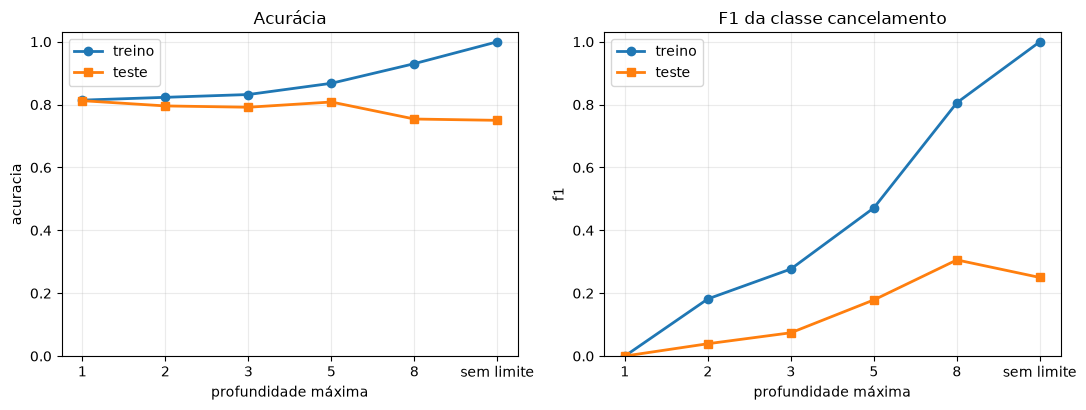

In [7]:
ordem = ["1", "2", "3", "5", "8", "sem limite"]
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.2))

for eixo, metrica, titulo in [
    (eixos[0], "acuracia", "Acurácia"),
    (eixos[1], "f1", "F1 da classe cancelamento"),
]:
    for particao, marcador in [("treino", "o"), ("teste", "s")]:
        serie = (
            desempenho.query("particao == @particao")
            .set_index("profundidade")
            .loc[ordem]
        )
        eixo.plot(
            ordem,
            serie[metrica],
            marker=marcador,
            linewidth=2,
            label=particao,
        )
    eixo.set(
        title=titulo,
        xlabel="profundidade máxima",
        ylabel=metrica,
        ylim=(0, 1.03),
    )
    eixo.grid(alpha=0.25)
    eixo.legend()

plt.tight_layout()
plt.show()

### Poda: controlar complexidade

- **Pré-poda:** interrompe o crescimento durante o treinamento, por exemplo com profundidade máxima, mínimo de exemplos para dividir ou mínimo por folha.
- **Pós-poda:** começa com uma árvore maior e substitui subárvores pouco confiáveis por folhas.

Uma árvore menor costuma ser mais fácil de comunicar e pode generalizar melhor. Porém, simplificação excessiva também elimina padrões reais. Parâmetros de poda devem ser escolhidos com validação dentro do treino; o teste final não deve virar ferramenta de ajuste.

## 7. Importância de atributos: uma pista, não uma causa

A importância calculada pela árvore soma quanto cada atributo reduziu a impureza nas divisões. Ela ajuda a descrever o modelo, mas exige cautela:

- atributos correlacionados podem dividir ou concentrar a importância;
- variáveis com muitos pontos de corte podem receber preferência;
- importância zero significa apenas que aquela árvore não usou o atributo;
- importância alta não prova que alterar o atributo mudará o resultado.

A figura usa a árvore de profundidade 3 como exemplo interpretável.

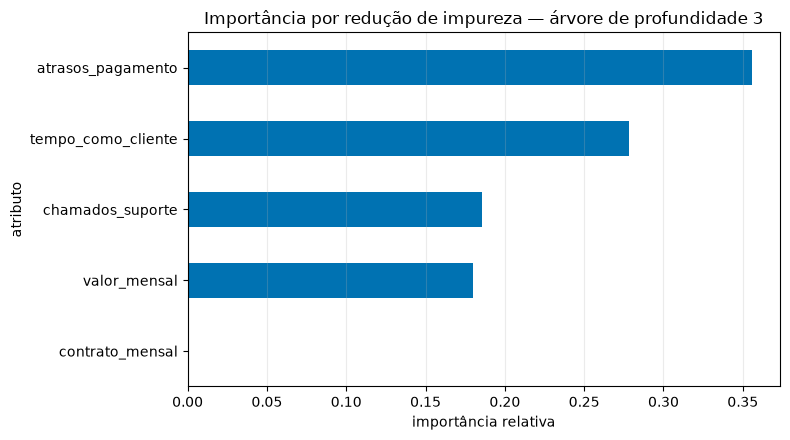

,importancia
atrasos_pagamento,0.356
tempo_como_cliente,0.279
chamados_suporte,0.186
valor_mensal,0.180
contrato_mensal,0.000


In [8]:
arvore_interpretavel = modelos[3]
importancias = (
    pd.Series(
        arvore_interpretavel.feature_importances_,
        index=X.columns,
        name="importancia",
    )
    .sort_values()
)

ax = importancias.plot.barh(
    figsize=(8, 4.5),
    color="#0072B2",
)
ax.set(
    title="Importância por redução de impureza — árvore de profundidade 3",
    xlabel="importância relativa",
    ylabel="atributo",
)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

importancias.sort_values(ascending=False).to_frame().round(3)

### Uma armadilha de mineração de dados

Um identificador único pode criar folhas puras ao separar pessoas individualmente, mas não constitui um padrão generalizável. Pureza de treino não é suficiente para justificar um atributo.

Antes de ajustar a árvore, devem ser removidos identificadores técnicos e atributos indisponíveis no momento da previsão. Depois, regras e importâncias precisam ser avaliadas com conhecimento do domínio e dados separados.

## Atividades

> **U05-NB04-V01 — Verifique seu entendimento:** por que um identificador único pode produzir folhas puras e, ainda assim, ser inútil para classificar novos objetos?

> **U05-NB04-E01 — Exercício:** reproduza manualmente o índice Gini da raiz, dos dois grupos criados por $\text{atrasos}\leq1{,}5$, a impureza ponderada e a redução de impureza. Relacione cada fração às contagens da tabela.

> **U05-NB04-E02 — Leitura da árvore:** usando a figura, as regras textuais e a tabela de novos casos, descreva o caminho percorrido por **perfil 1** e **perfil 2**. Informe folha, classe e probabilidade de cancelamento exibida. Explique por que essa probabilidade não é garantia individual.

> **U05-NB04-E03 — Complexidade:** compare treino e teste na tabela e nos gráficos de profundidade. Indique uma profundidade defensável para comunicação e generalização, justificando com acurácia, F1, número de folhas e diferença treino–teste. Não trate a escolha como universal.

## Síntese

- Árvores classificam percorrendo perguntas da raiz até uma folha.
- Cada caminho pode ser expresso como uma regra **SE–ENTÃO**.
- Gini mede mistura de classes; a árvore procura reduzi-la.
- Crescimento guloso não garante a única ou a melhor árvore possível.
- Árvores profundas podem memorizar ruído e perder generalização.
- Poda equilibra desempenho, estabilidade e interpretabilidade.
- Importância de atributos descreve o uso no modelo, não efeito causal.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 6, seção 6.2.
- SCIKIT-LEARN DEVELOPERS. *User Guide: Decision Trees*. Documentação da biblioteca utilizada nos exemplos computacionais.